# GRA: signum imgnet (resnet)

project = ```GRA```, host = ```chewie```, device = ```cuda:1```

## Goals:

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


def _plot(results, intvl=slice(-21, None), smooth=None, ylim=None, figsize=(9, 4), dpi=100):

    fig, ax = create_figure(1, 1, figsize=figsize, dpi=dpi)

    for i, (k, d) in enumerate(results.items()):
        color = f"C{i}"

        mu = d['test_acc'].mean(0)
        sd = d['test_acc'].std(0)

        if smooth is not None:
            mu = smooth_savgol(mu, smooth, polyorder=3)
            sd = smooth_savgol(sd, smooth, polyorder=3)
            
        xs = np.arange(1, len(mu) + 1)

        xs = xs[intvl]
        mu = mu[intvl]
        sd = sd[intvl]

        ax.plot(xs, mu + sd, color=color, ls='--', lw=0.8, alpha=1.0)
        ax.plot(xs, mu, color=color, label=k, marker='.')
        ax.plot(xs, mu - sd, color=color, ls='--', lw=0.8, alpha=1.0)
        plt.fill_between(xs, mu - sd, mu + sd, color=color, alpha=0.1)

    if ylim is not None:
        ax.set(ylim=ylim)

    ax.legend()
    move_legend(ax, (1.01, 1.01))
    plt.show()

    return

In [3]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Main

In [4]:
from optimizers import *
from test.test import *

## ImageNet32

`batch_size=256`

In [5]:
cfg = TrainConfig(
    dataset='ImageNet32',
    batch_size=512,
    epochs=100,
    device=device,
    data_on_device=True,
    verbose=True,
    amp=False,
)

### Signum

In [6]:
experiments = []


for lr in [5e-4, 1e-3, 5e-3]:
    for beta1 in [0.95]:
        for weight_decay in [0.1]:

            opt_kws = dict(lr=lr, momentum=beta1, weight_decay=weight_decay)
            base_str = f"lr={lr},beta={beta1},wd={weight_decay}"
            
            experiments.extend([
                Experiment(
                    name=f'Rel. Signum ({base_str},mass=10)',
                    opt_fn=make_opt(RelativisticSignum, mass=10, **opt_kws)),
#                 Experiment(
#                     name=f'Rel. Signum ({base_str},mass=5)',
#                     opt_fn=make_opt(RelativisticSignum, mass=5, **opt_kws)),
                Experiment(
                    name=f'Rel. Signum ({base_str},mass=1)',
                    opt_fn=make_opt(RelativisticSignum, mass=1, **opt_kws)),
#                 Experiment(
#                     name=f'Rel. Signum ({base_str},mass=0.1)',
#                     opt_fn=make_opt(RelativisticSignum, mass=0.1, **opt_kws)),
                Experiment(
                    name=f'Signum ({base_str},dampening=0.0)',
                    opt_fn=make_opt(SignSGD, dampening=0.0, **opt_kws)),
#                 Experiment(
#                     name=f'Signum ({base_str},dampening=0.1)',
#                     opt_fn=make_opt(SignSGD, dampening=0.1, **opt_kws)),
#                 Experiment(
#                     name=f'Signum ({base_str},dampening=0.5)',
#                     opt_fn=make_opt(SignSGD, dampening=0.5, **opt_kws)),
                Experiment(
                    name=f'AdamW ({base_str})',
                    opt_fn=make_opt(torch.optim.AdamW, lr=lr,
                                    betas=(beta1, beta1),
                                    weight_decay=weight_decay)),
            ])
            
print(len(experiments))

12

In [7]:
print(experiments)

[
    Experiment(
        name='Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=10)',
        opt_fn=<function make_opt.<locals>._fn at 0x716a6626e3e0>
    ),
    Experiment(
        name='Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=1)',
        opt_fn=<function make_opt.<locals>._fn at 0x716a6626e340>
    ),
    Experiment(
        name='Signum (lr=0.0005,beta=0.95,wd=0.1,dampening=0.0)',
        opt_fn=<function make_opt.<locals>._fn at 0x716a6626e480>
    ),
    Experiment(
        name='AdamW (lr=0.0005,beta=0.95,wd=0.1)',
        opt_fn=<function make_opt.<locals>._fn at 0x716a6626e520>
    ),
    Experiment(
        name='Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=10)',
        opt_fn=<function make_opt.<locals>._fn at 0x716a6626e5c0>
    ),
    Experiment(
        name='Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=1)',
        opt_fn=<function make_opt.<locals>._fn at 0x716a6626e660>
    ),
    Experiment(
        name='Signum (lr=0.001,beta=0.95,wd=0.1,dampening=0.0)',
        opt_fn=<function make_opt.<locals>._fn at 0x716a6626e700>
    ),
    Experiment(
        name='AdamW (lr=0.001,beta=0.95,wd=0.1)',
        opt_fn=<function make_opt.<locals>._fn at 0x716a6626e7a0>
    ),
    Experiment(
        name='Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=10)',
        opt_fn=<function make_opt.<locals>._fn at 0x716a6626e840>
    ),
    Experiment(
        name='Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=1)',
        opt_fn=<function make_opt.<locals>._fn at 0x716a6626e8e0>
    ),
    Experiment(
        name='Signum (lr=0.005,beta=0.95,wd=0.1,dampening=0.0)',
        opt_fn=<function make_opt.<locals>._fn at 0x716a6626e980>
    ),
    Experiment(
        name='AdamW (lr=0.005,beta=0.95,wd=0.1)',
        opt_fn=<function make_opt.<locals>._fn at 0x716a6626ea20>
    )
]

In [ ]:
%%time


results = run_experiments(
    experiments,
    cfg=cfg,
    model_class=ResNet18,
    seeds=[0],
)

--- Training (ImageNet32) ---

Model: ResNet18 | seed=0
Optimizer: RelativisticSignum

RelativisticSignum (
Parameter Group 0
    lr: 0.0005
    mass: 10
    momentum: 0.95
    weight_decay: 0.1
)

Epoch    1/100:  Train Loss 4.7883  |  Test Acc 19.40%

Epoch    5/100:  Train Loss 2.3224  |  Test Acc 35.00%

Epoch   10/100:  Train Loss 1.7325  |  Test Acc 33.64%

...

Epoch   65/100:  Train Loss 1.0144  |  Test Acc 32.38%

Epoch   70/100:  Train Loss 1.0173  |  Test Acc 31.71%

Epoch   75/100:  Train Loss 0.9852  |  Test Acc 32.07%

Epoch   80/100:  Train Loss 0.9799  |  Test Acc 32.02%

Epoch   85/100:  Train Loss 0.9688  |  Test Acc 32.20%

Training time:

- `ImageNet32`: **???**
- `CIFAR10`: **???**
- `MNIST`: **17h 31s**

In [ ]:
save_obj(results, file_name='ImageNet32_results_jan04.npy', save_dir=tmp_dir)

In [20]:
avg_scores = {k: np.round(d['test_acc'].mean(0)[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Signum (lr=0.005,beta=0.95,wd=0.1,dampening=0.0)': 4.44,
 'AdamW (lr=0.005,beta=0.95,wd=0.1)': 28.81,
 'Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=10)': 29.53,
 'Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=1)': 29.94,
 'AdamW (lr=0.0005,beta=0.95,wd=0.1)': 31.4,
 'Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=10)': 31.58,
 'Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=1)': 32.03,
 'Signum (lr=0.0005,beta=0.95,wd=0.1,dampening=0.0)': 32.28,
 'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=10)': 35.27,
 'AdamW (lr=0.001,beta=0.95,wd=0.1)': 35.42,
 'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=1)': 36.0,
 'Signum (lr=0.001,beta=0.95,wd=0.1,dampening=0.0)': 37.27}

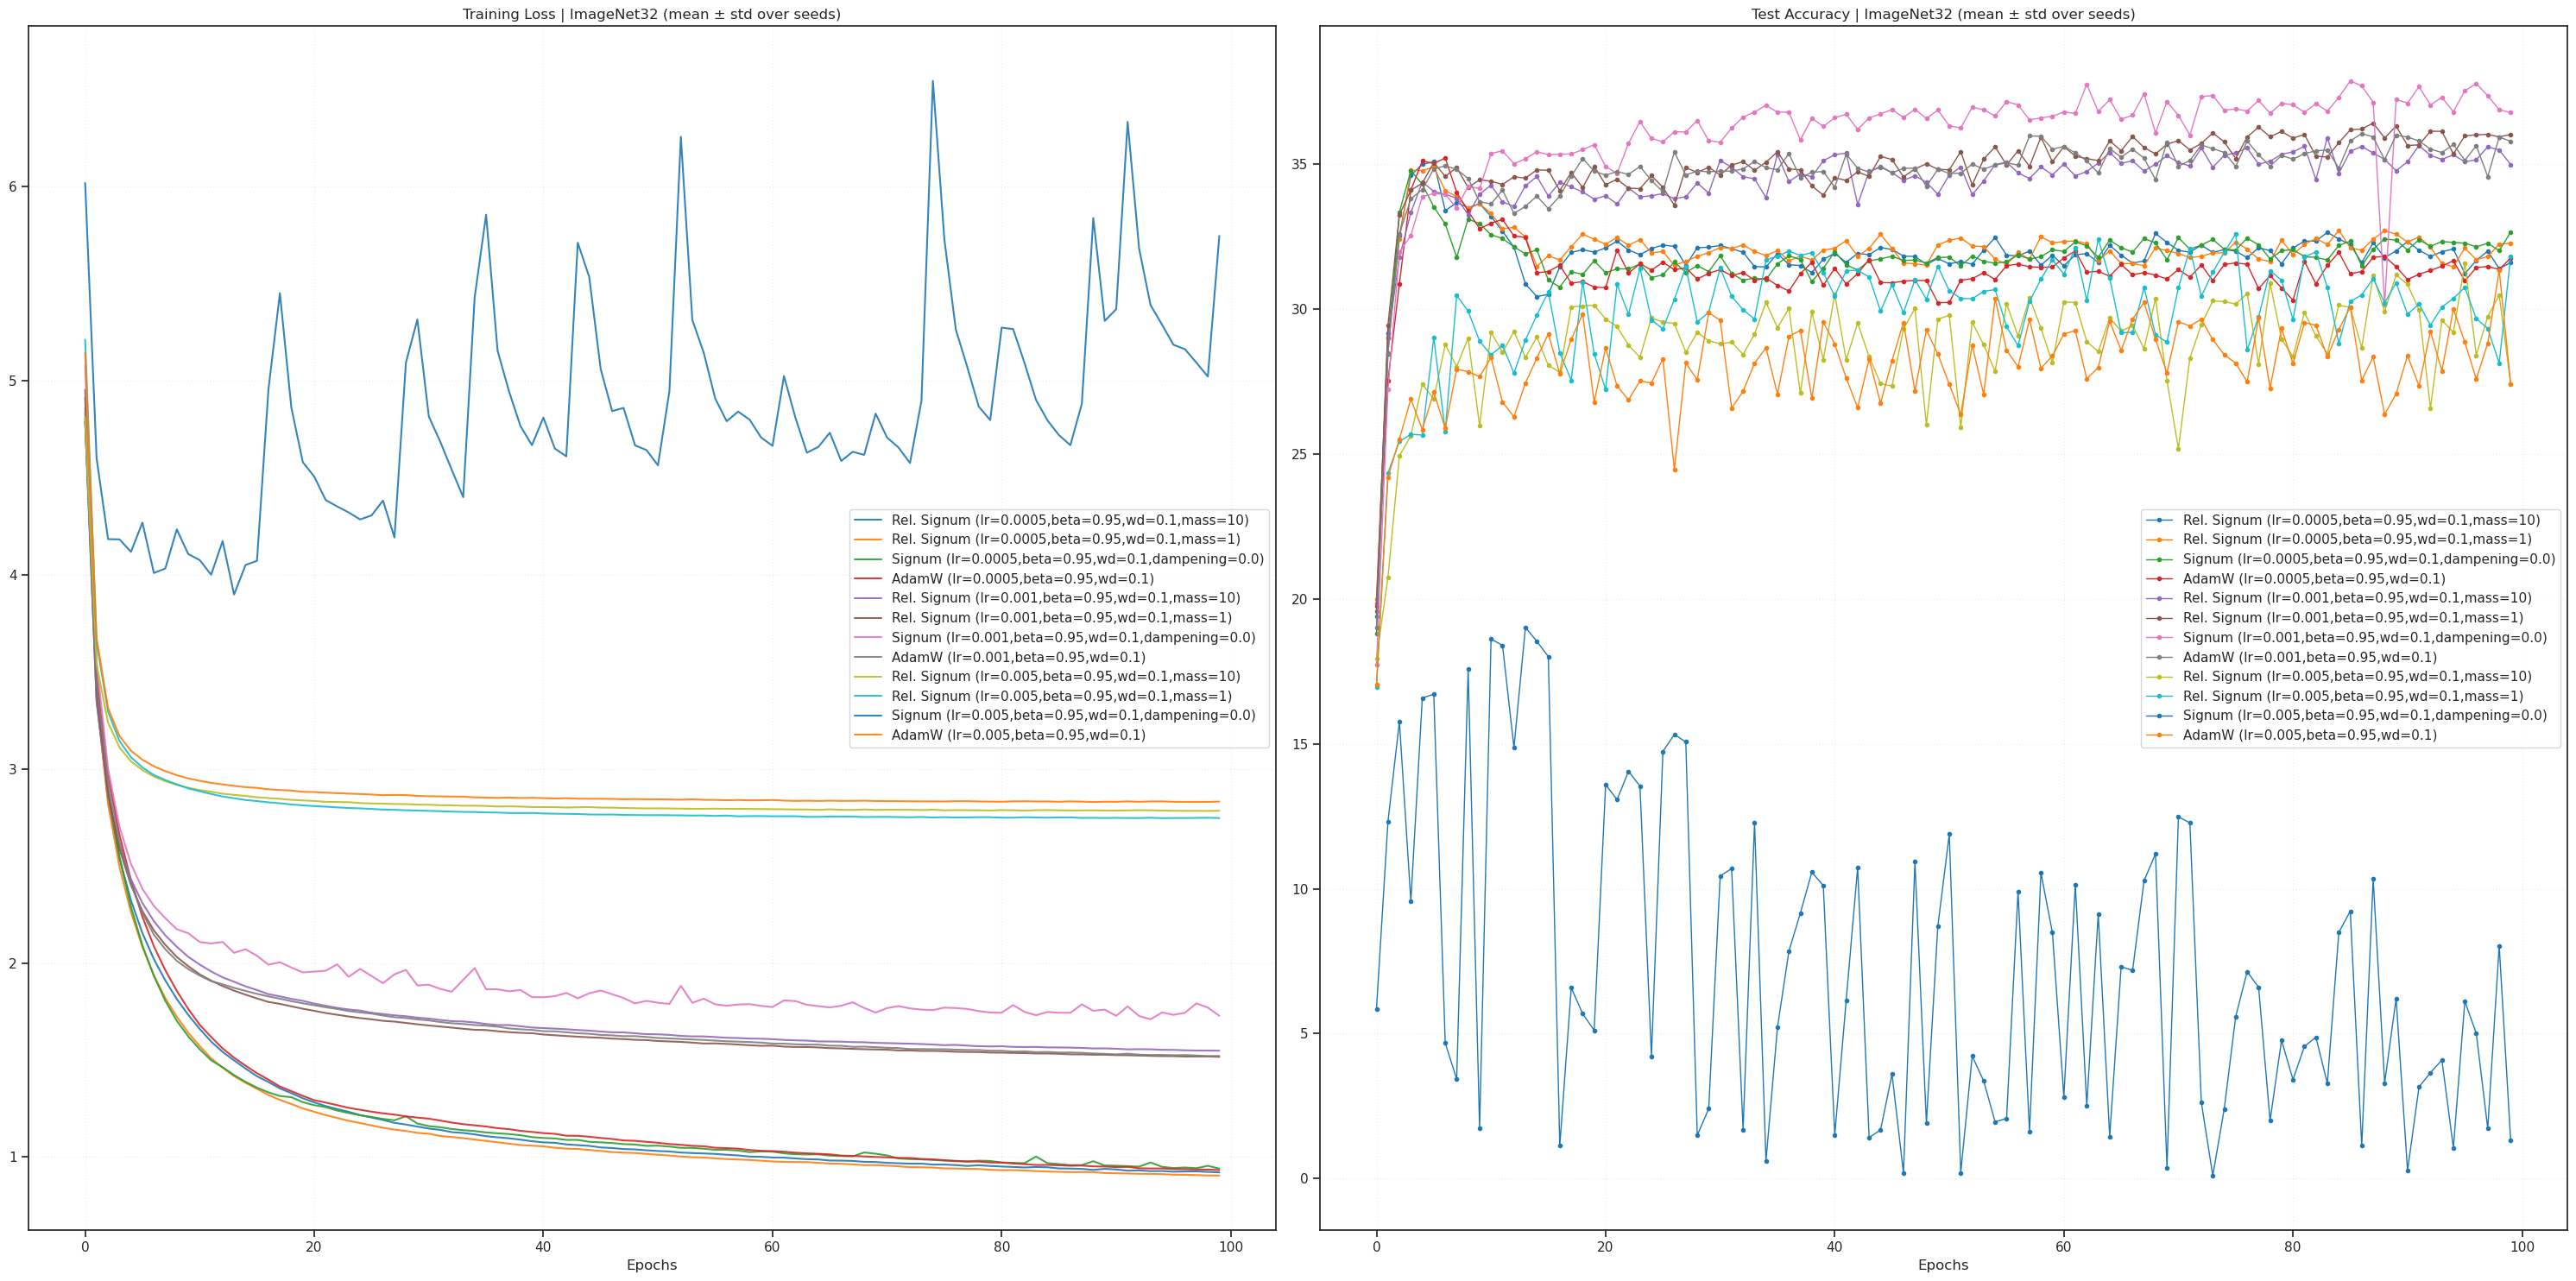

In [21]:
plot_results(results, title="ImageNet32 (mean ± std over seeds)", figsize=(30, 15))

In [22]:
optimizer_names = sorted(set([
    k.split('(')[0].strip()
    for k in results
]))

print(optimizer_names)

['AdamW', 'Rel. Signum', 'Signum']

In [23]:
n_last_timepoints = 10

model_accuracies = collections.defaultdict(dict)

for k, d in results.items():
    name = k.split('(')[0].strip()
    acc = d['test_acc'].mean(0)[-n_last_timepoints:].mean()
    model_accuracies[name][k] = acc

model_accuracies = dict(sorted(model_accuracies.items()))
    
model_accuracies = {
    k: dict(sorted(d.items(), key=lambda t: t[1]))
    for k, d in model_accuracies.items()
}

In [24]:
print(model_accuracies)

{
    'AdamW': {
        'AdamW (lr=0.005,beta=0.95,wd=0.1)': 28.692,
        'AdamW (lr=0.0005,beta=0.95,wd=0.1)': 31.3728,
        'AdamW (lr=0.001,beta=0.95,wd=0.1)': 35.544
    },
    'Rel. Signum': {
        'Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=10)': 29.386600000000005,
        'Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=1)': 29.961199999999998,
        'Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=10)': 31.816399999999998,
        'Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=1)': 32.014,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=10)': 35.28600000000001,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=1)': 35.89500000000001
    },
    'Signum': {
        'Signum (lr=0.005,beta=0.95,wd=0.1,dampening=0.0)': 3.4453999999999994,
        'Signum (lr=0.0005,beta=0.95,wd=0.1,dampening=0.0)': 32.262,
        'Signum (lr=0.001,beta=0.95,wd=0.1,dampening=0.0)': 37.230000000000004
    }
}

In [25]:
print({k: np.mean(list(d.values())) for k, d in model_accuracies.items()})

{'AdamW': 31.869600000000002, 'Rel. Signum': 32.3932, 'Signum': 24.312466666666666}

In [26]:
n_top_fits = 2

best_n_models = {
    k: dict(list(d.items())[-n_top_fits:])
    for k, d in model_accuracies.items()
}
print(best_n_models)

{
    'AdamW': {'AdamW (lr=0.0005,beta=0.95,wd=0.1)': 31.3728, 'AdamW (lr=0.001,beta=0.95,wd=0.1)': 35.544},
    'Rel. Signum': {
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=10)': 35.28600000000001,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=1)': 35.89500000000001
    },
    'Signum': {
        'Signum (lr=0.0005,beta=0.95,wd=0.1,dampening=0.0)': 32.262,
        'Signum (lr=0.001,beta=0.95,wd=0.1,dampening=0.0)': 37.230000000000004
    }
}

In [27]:
best_n_models_strings = [x for d in best_n_models.values() for x in list(d)]

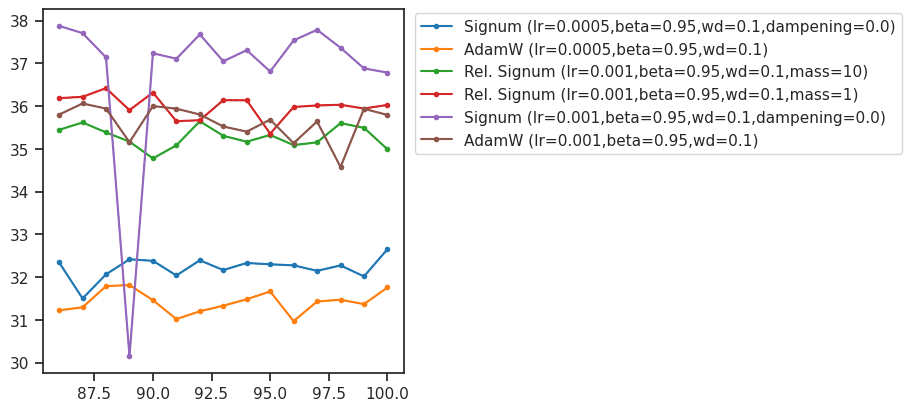

In [32]:
selected_results = {
    k: v for k, v in results.items()
    if k in best_n_models_strings
}

_plot(selected_results, intvl=slice(-15, None))

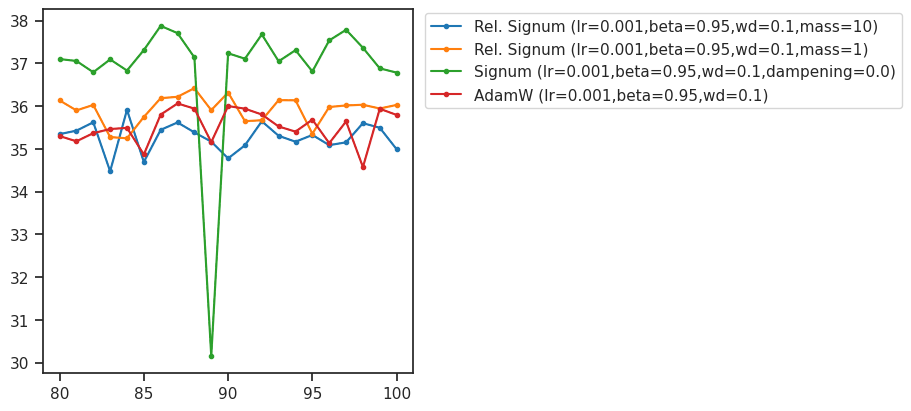

In [33]:
selected_results = {
    k: v for k, v in results.items()
    if 'lr=0.001,beta=0.95' in k
}

_plot(selected_results, intvl=slice(-21, None))

In [36]:
experiments = []


for lr in [1e-3]:
    for beta1 in [0.95]:
        for weight_decay in [0.1]:

            opt_kws = dict(lr=lr, momentum=beta1, weight_decay=weight_decay)
            base_str = f"lr={lr},beta={beta1},wd={weight_decay}"

            experiments.extend([
                Experiment(
                    name=f'Rel. Signum ({base_str},mass=0.5)',
                    opt_fn=make_opt(RelativisticSignum, mass=0.5, **opt_kws)),
                Experiment(
                    name=f'Rel. Signum ({base_str},mass=0.1)',
                    opt_fn=make_opt(RelativisticSignum, mass=0.1, **opt_kws)),
                Experiment(
                    name=f'Rel. Signum ({base_str},mass=0.01)',
                    opt_fn=make_opt(RelativisticSignum, mass=0.01, **opt_kws)),
            ])
            
print(len(experiments))

3

In [37]:
%%time


results_new = run_experiments(
    experiments,
    cfg=cfg,
    model_class=ResNet18,
    seeds=[0],
)

--- Training (ImageNet32) ---

Model: ResNet18 | seed=0
Optimizer: RelativisticSignum

RelativisticSignum (
Parameter Group 0
    lr: 0.001
    mass: 0.5
    momentum: 0.95
    weight_decay: 0.1
)

Epoch    1/100:  Train Loss 4.9798  |  Test Acc 19.35%

Epoch    5/100:  Train Loss 2.3936  |  Test Acc 34.57%

Epoch   10/100:  Train Loss 1.9728  |  Test Acc 34.67%

...

Epoch   90/100:  Train Loss 1.6526  |  Test Acc 37.65%

Epoch   95/100:  Train Loss 1.6485  |  Test Acc 37.19%

Epoch  100/100:  Train Loss 1.6454  |  Test Acc 37.60%

Finished in 16184.4s

CPU times: user 13h 29min 28s, sys: 1min 25s, total: 13h 30min 54s
Wall time: 13h 29min 58s


In [38]:
combined = results | results_new

In [39]:
save_obj(combined, file_name='ImageNet32_results_jan06.npy', save_dir=tmp_dir)

[PROGRESS] 'ImageNet32_results_jan06.npy' saved at
/home/hadi/Dropbox/git/jb-progress-2025/tmp

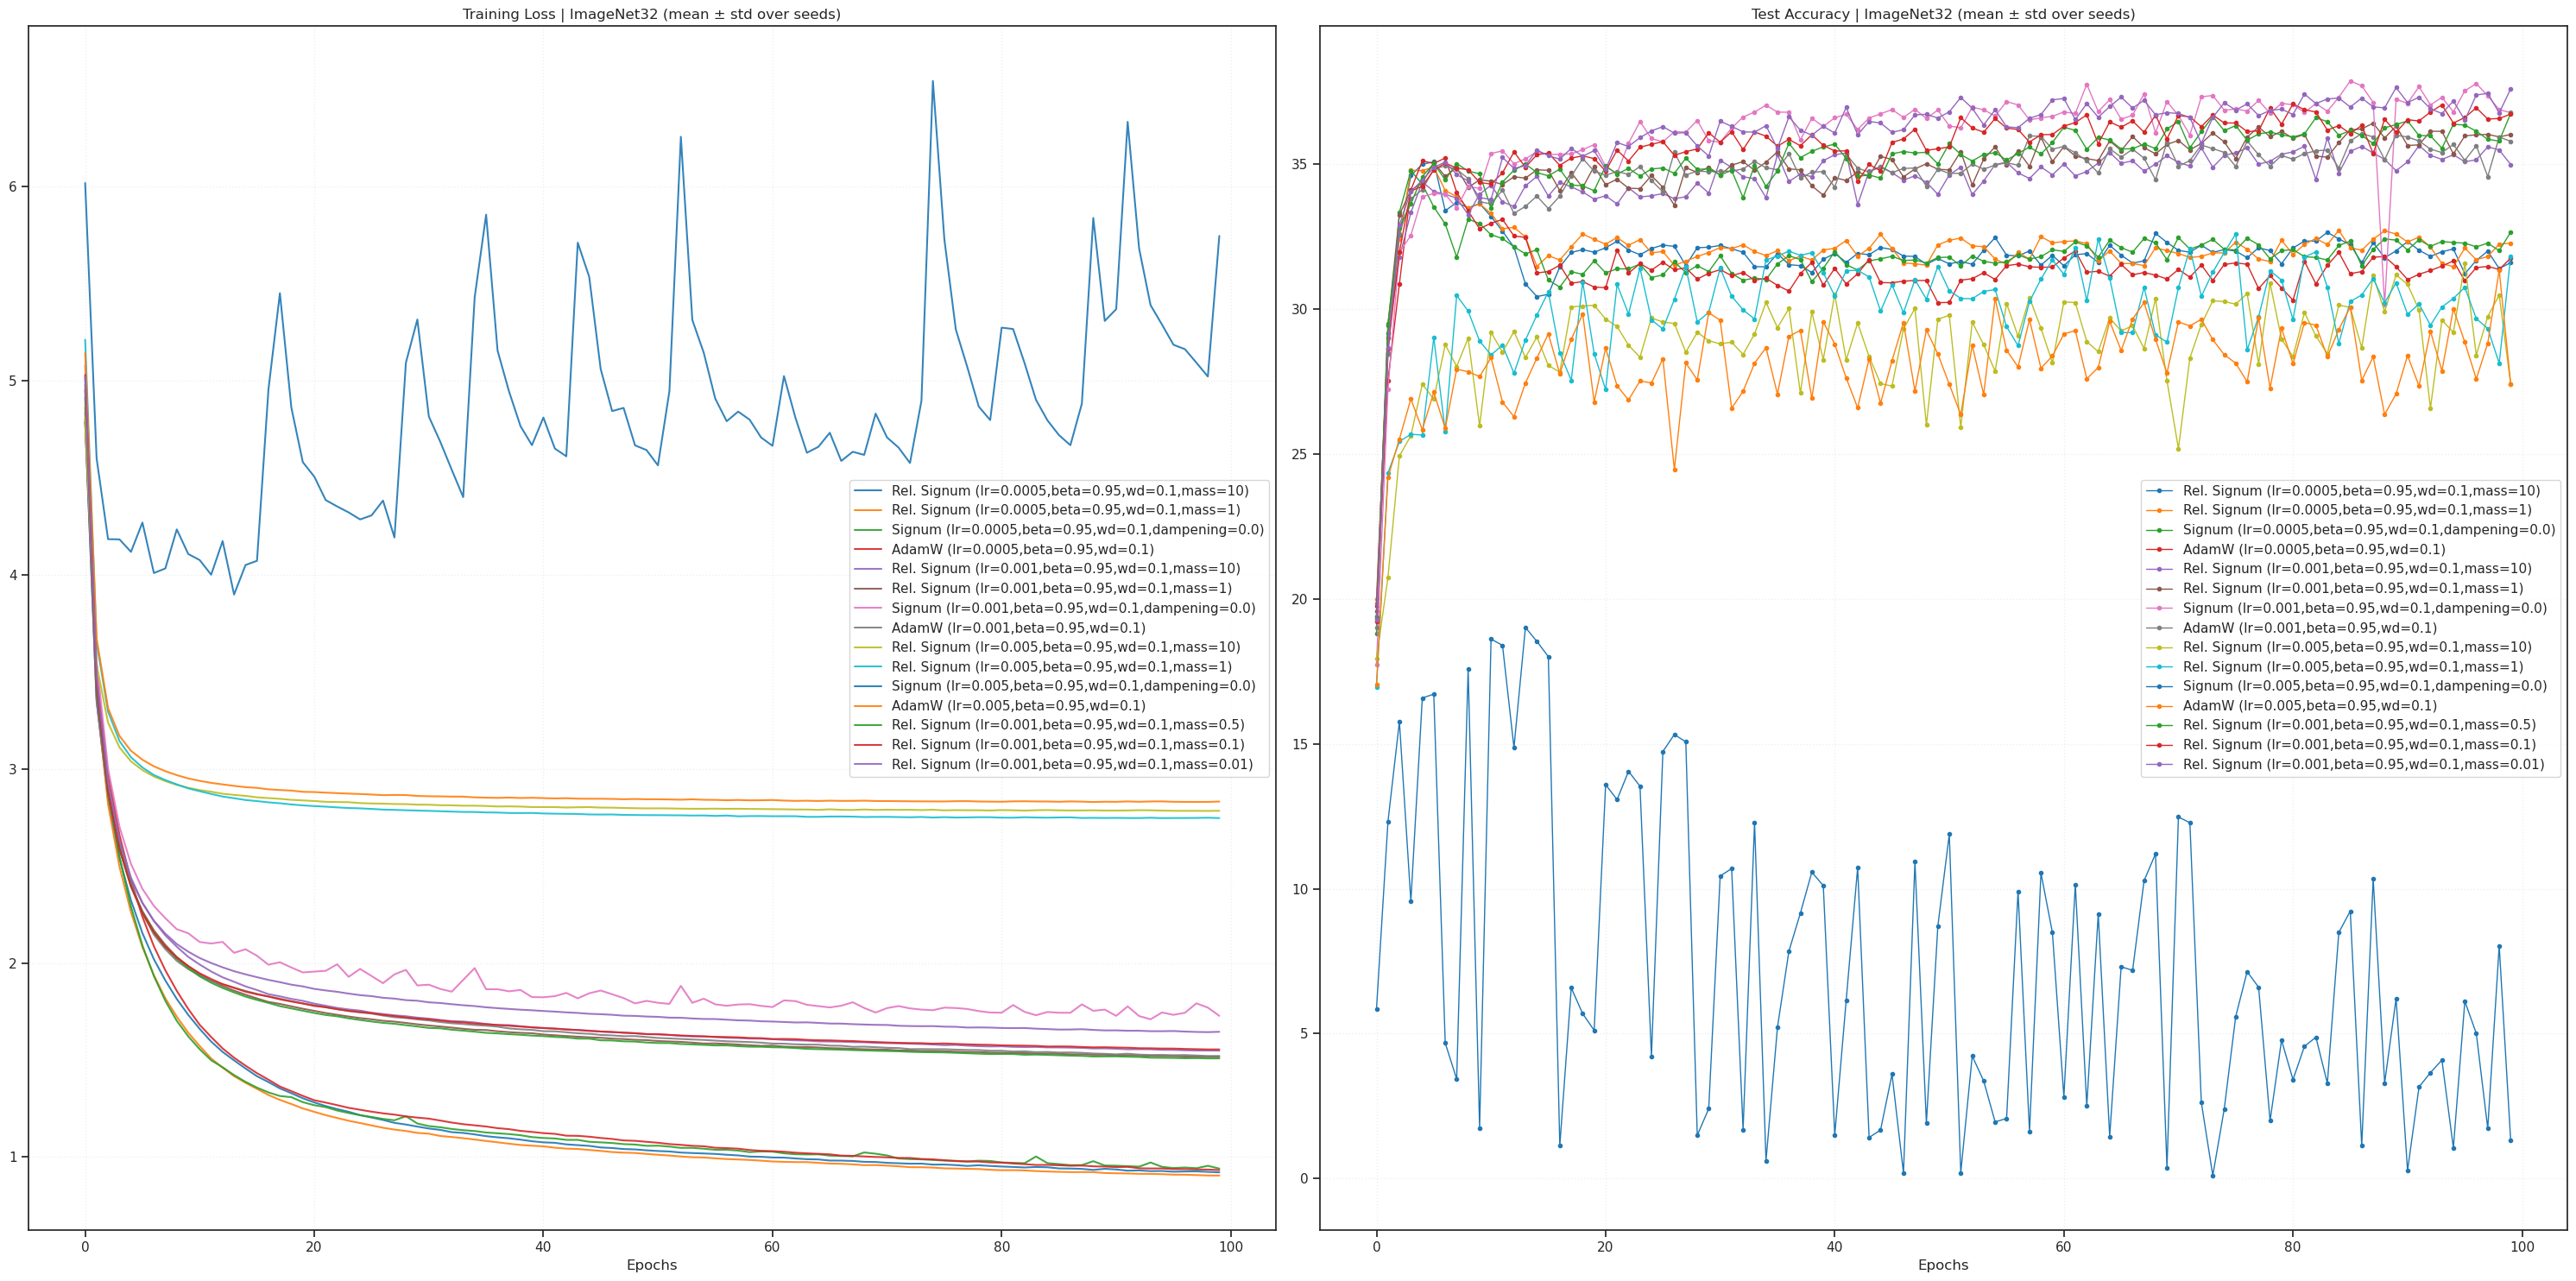

In [49]:
plot_results(combined, title="ImageNet32 (mean ± std over seeds)", figsize=(30, 15))

In [42]:
n_last_timepoints = 10

model_accuracies = collections.defaultdict(dict)

for k, d in combined.items():
    name = k.split('(')[0].strip()
    acc = d['test_acc'].mean(0)[-n_last_timepoints:].mean()
    model_accuracies[name][k] = acc

model_accuracies = dict(sorted(model_accuracies.items()))
    
model_accuracies = {
    k: dict(sorted(d.items(), key=lambda t: t[1]))
    for k, d in model_accuracies.items()
}

In [43]:
print(model_accuracies)

{
    'AdamW': {
        'AdamW (lr=0.005,beta=0.95,wd=0.1)': 28.692,
        'AdamW (lr=0.0005,beta=0.95,wd=0.1)': 31.3728,
        'AdamW (lr=0.001,beta=0.95,wd=0.1)': 35.544
    },
    'Rel. Signum': {
        'Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=10)': 29.386600000000005,
        'Rel. Signum (lr=0.005,beta=0.95,wd=0.1,mass=1)': 29.961199999999998,
        'Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=10)': 31.816399999999998,
        'Rel. Signum (lr=0.0005,beta=0.95,wd=0.1,mass=1)': 32.014,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=10)': 35.28600000000001,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=1)': 35.89500000000001,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=0.5)': 36.13080000000001,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=0.1)': 36.6742,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=0.01)': 37.1022
    },
    'Signum': {
        'Signum (lr=0.005,beta=0.95,wd=0.1,dampening=0.0)': 3.4453999999999994,
        'Signum (lr=0.0005,beta=0.95,wd=0.1,dampening=0.0)': 32.262,
        'Signum (lr=0.001,beta=0.95,wd=0.1,dampening=0.0)': 37.230000000000004
    }
}

In [44]:
print({k: np.mean(list(d.values())) for k, d in model_accuracies.items()})

{'AdamW': 31.869600000000002, 'Rel. Signum': 33.80737777777778, 'Signum': 24.312466666666666}

In [45]:
n_top_fits = 2

best_n_models = {
    k: dict(list(d.items())[-n_top_fits:])
    for k, d in model_accuracies.items()
}
print(best_n_models)

{
    'AdamW': {'AdamW (lr=0.0005,beta=0.95,wd=0.1)': 31.3728, 'AdamW (lr=0.001,beta=0.95,wd=0.1)': 35.544},
    'Rel. Signum': {
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=0.1)': 36.6742,
        'Rel. Signum (lr=0.001,beta=0.95,wd=0.1,mass=0.01)': 37.1022
    },
    'Signum': {
        'Signum (lr=0.0005,beta=0.95,wd=0.1,dampening=0.0)': 32.262,
        'Signum (lr=0.001,beta=0.95,wd=0.1,dampening=0.0)': 37.230000000000004
    }
}

In [46]:
best_n_models_strings = [x for d in best_n_models.values() for x in list(d)]

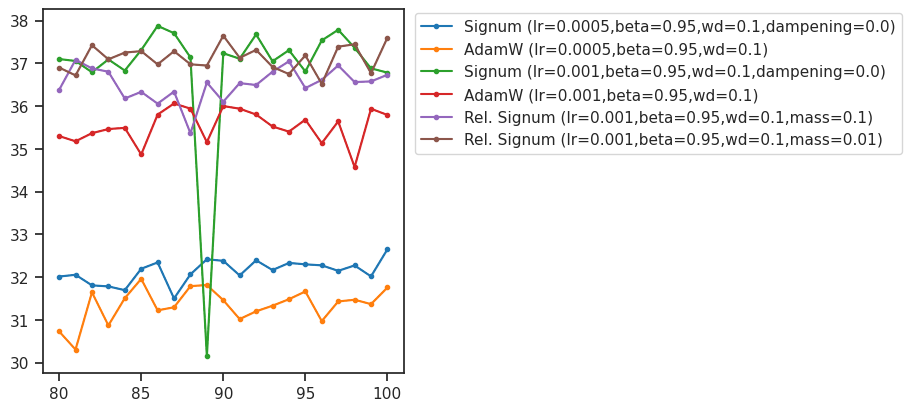

In [48]:
selected_results = {
    k: v for k, v in combined.items()
    if k in best_n_models_strings
}

_plot(selected_results, intvl=slice(-21, None))

In [50]:
experiments = []


for lr in [1e-3]:
    for beta1 in [0.95]:
        for weight_decay in [0.1]:

            opt_kws = dict(lr=lr, momentum=beta1, weight_decay=weight_decay)
            base_str = f"lr={lr},beta={beta1},wd={weight_decay}"

            experiments.extend([
                Experiment(
                    name=f'Rel. Signum ({base_str},mass=0.01)',
                    opt_fn=make_opt(RelativisticSignum, mass=0.01, **opt_kws)),
                Experiment(
                    name=f'Rel. Signum ({base_str},mass=0.001)',
                    opt_fn=make_opt(RelativisticSignum, mass=0.001, **opt_kws)),
                Experiment(
                    name=f'Signum ({base_str},dampening=0.05)',
                    opt_fn=make_opt(SignSGD, dampening=0.05, **opt_kws)),
            ])
            
print(len(experiments))

3

In [ ]:
%%time


results_with_seed = run_experiments(
    experiments,
    cfg=cfg,
    model_class=ResNet18,
    seeds=[0, 1, 2, 3],
)

--- Training (ImageNet32) ---

Model: ResNet18 | seed=0
Optimizer: RelativisticSignum

RelativisticSignum (
Parameter Group 0
    lr: 0.001
    mass: 0.01
    momentum: 0.95
    weight_decay: 0.1
)

Epoch    1/100:  Train Loss 5.0193  |  Test Acc 19.27%

Epoch    5/100:  Train Loss 2.4396  |  Test Acc 34.45%

Epoch   10/100:  Train Loss 2.0581  |  Test Acc 33.85%

...

Epoch   45/100:  Train Loss 1.7381  |  Test Acc 36.42%

Epoch   50/100:  Train Loss 1.7241  |  Test Acc 36.60%

Epoch   55/100:  Train Loss 1.7115  |  Test Acc 36.88%

Epoch   60/100:  Train Loss 1.6997  |  Test Acc 37.22%

Epoch   65/100:  Train Loss 1.6912  |  Test Acc 36.99%

In [ ]:
results_final = combined | results_with_seed

In [ ]:
save_obj(results_final, file_name='ImageNet32_results_jan08.npy', save_dir=tmp_dir)

In [ ]:
plot_results(results_final, title="ImageNet32 (mean ± std over seeds)", figsize=(30, 15))